In [1]:
%load_ext autoreload
%autoreload 2

import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import seaborn as sns
import yfinance as yf
import warnings
from IPython.display import display

root_path = Path.cwd().parent
if str(root_path) not in sys.path:
    sys.path.append(str(root_path))

from src.simulation import MarketSimulator
from src.metrics import MarketMetrics, plot_susceptibility_curve
import scipy.stats as sistats

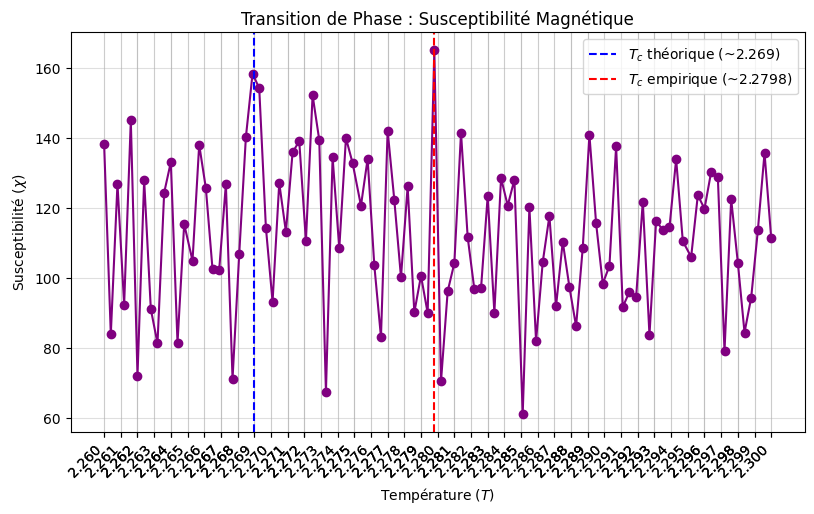

In [2]:
list_T = np.linspace(2.26, 2.3, 100)
dict_results = {}
counts = 5
N_agents = 1000

for T in list_T:
    susceptibilities_for_T = []
    
    for _ in range(counts):
        sim = MarketSimulator(
            N=N_agents,     
            T=T,        
            J=1.0,       
            h_0=0.0,          
            Delta_t=1000, 
            P_0=100,  
            lambd_0=100  
        )
        
        filename = sim.run()
        analyzer = MarketMetrics(filename)
        susceptibility = analyzer.calculate_susceptibility(N_agents, T)
        
        susceptibilities_for_T.append(susceptibility)
    
    # Calcul de la moyenne sur les 5 simulations indépendantes
    mean_susceptibility = np.mean(susceptibilities_for_T)
    
    # Stockage dans le dictionnaire pour le tracé de la courbe
    dict_results[f"{T:.4f}"] = mean_susceptibility

# Tracé final avec la susceptibilité moyennée (courbe beaucoup plus lisse)
T_c = plot_susceptibility_curve(dict_results)

In [3]:
# Création de la figure avec 3 sous-graphiques (subplots)
def curves(df):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # 1. Graphique du Prix
    ax1.semilogy(df['time'], df['P_history'], color='blue', lw=1.5)
    ax1.set_ylabel('ln Prix ($\ln P_t$)')
    ax1.set_title('Historique du Marché Ising')
    ax1.grid(alpha=0.3)

    # 2. Graphique des Rendements
    ax2.plot(df['time'], df['r_history'], color='red', lw=1)
    ax2.axhline(0, color='black', lw=0.8, ls='--')
    ax2.set_ylabel('Rendements ($r_t$)')
    ax2.grid(alpha=0.3)

    # 3. Graphique de la Magnétisation
    ax3.plot(df['time'], df['m_history'], color='green', lw=1)
    ax3.axhline(0, color='black', lw=0.8, ls='--')
    ax3.set_ylabel('Magnétisation ($M_t$)')
    ax3.set_xlabel('Temps (Steps)')
    ax3.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

<>:7: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:7: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/var/folders/0q/z_dwszqd10scbmvs1r972gdh0000gn/T/ipykernel_2133/2893522700.py:7: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax1.set_ylabel('ln Prix ($\ln P_t$)')


In [4]:
def temp_map(T_c, N=1000, J=1.0, h_0=0.0, Delta_t=8000, P_0=100):
    # 1. Paramétrage des plages de test
    # On se focalise autour de ton Tc critique pour voir la transition
    temp_range = np.linspace(2.15, 2.8, 20)   
    # On teste de très liquide (200) à peu liquide (20)
    lambda_range = np.linspace(20, 200, 10)

    # Initialisation de la matrice pour stocker le Kurtosis
    kurt_matrix = np.zeros((len(temp_range), len(lambda_range)))

    print("🚀 Lancement du scan de phase (36 simulations)... Cela peut prendre quelques minutes.")

    # 2. Boucle de simulation croisée
    for i, T in enumerate(temp_range):
        for j, L in enumerate(lambda_range):
            # On utilise des paramètres un peu plus légers pour que le scan soit rapide
            sim = MarketSimulator(
                N=N,     
                T=T,        
                J=J,       
                h_0=h_0,      
                Delta_t=Delta_t, 
                P_0=P_0,  
                lambd_0=L  
            )
            
            # On lance la simulation
            filename = sim.run() 
            
            # On analyse directement le DataFrame en mémoire (plus rapide que lire/écrire des fichiers)
            df = pd.read_parquet(filename)
            analyzer = MarketMetrics(df)
            stats = analyzer.analyze_returns()
            
            # On stocke le Kurtosis
            current_kurt = stats["Excès de Kurtosis"]
            kurt_matrix[i, j] = current_kurt
        
        print(f"✅ Température T={T:.2f} terminée.")

    # 3. Création de la Heatmap avec Seaborn
    plt.figure(figsize=(12, 8))

    # On prépare les données
    df_heatmap = pd.DataFrame(
        kurt_matrix, 
        index=np.round(temp_range, 2), 
        columns=np.round(lambda_range, 0)
    )

    # On trace la heatmap
    sns.heatmap(df_heatmap, annot=True, fmt=".2f", cmap="YlOrRd")

    # --- CORRECTION DE LA LIGNE BLEUE ---
    # On cherche l'indice de la température la plus proche de 2.27
    tc_theorique = T_c
    # On trouve quelle ligne (0, 1, 2...) correspond au T le plus proche
    idx_proche = np.argmin(np.abs(temp_range - tc_theorique))

    # On ajoute la ligne (0.5 permet de centrer la ligne sur la case)
    plt.axhline(y=idx_proche + 0.5, color='blue', linestyle='--', linewidth=3, 
                label=f'Zone Critique (Tc ~ {T_c:.2f})')
    plt.xlabel('Lambda')
    plt.ylabel('T')
    plt.title("Phase Map : Excès de Kurtosis\n(Impact de la Température et de la Liquidité)")
    plt.legend()
    plt.show()

In [5]:
ticker = "BTC-USD"#"^GSPC" # S&P 500 (ou "BTC-USD" pour le Bitcoin)
data = yf.download(ticker, start="2019-01-01", end="2024-01-01")

# Calcul des rendements logarithmiques (log-returns)
# real_returns = np.log(data['Close'] / data['Close'].shift(1)).dropna()

# 1. Calcul des rendements log du Bitcoin si real_returns n'existe pas encore
if 'real_returns' not in locals():
    # On prend les prix de clôture ajustés 'Adj Close'
    # .pct_change() donne les rendements simples, on passe en log pour coller au modèle
    price_col = data['Adj Close'] if 'Adj Close' in data.columns else data['Close']
    real_returns = np.log(price_col / price_col.shift(1)).dropna()

r_real_raw = (real_returns - real_returns.mean()) / real_returns.std()
r_real_std = r_real_raw.values.squeeze()

# 2. Définition des cibles pour l'optimisation
# On utilise l'alias 'sistat' (scipy.stats) pour être 100% sûr d'avoir l'excès de Kurtosis fisherien
raw_kurt = sistats.kurtosis(real_returns)
raw_skew = sistats.skew(real_returns)

print(f"🎯 Cibles réelles du Bitcoin basées sur Yahoo Finance :")
TARGET_KURTOSIS = float(raw_kurt.item() if hasattr(raw_kurt, "item") else raw_kurt)
TARGET_SKEWNESS = float(raw_skew.item() if hasattr(raw_skew, "item") else raw_skew)
print(TARGET_KURTOSIS,TARGET_SKEWNESS)

def compare_to_reality(sim_returns, real_returns):
    plt.figure(figsize=(14, 6))
    
    # Standardisation (pour comparer des pommes avec des pommes)
    # On ramène les deux distributions à une moyenne de 0 et un écart-type de 1
    sim_std = (sim_returns - sim_returns.mean()) / sim_returns.std()
    real_std = (real_returns - real_returns.mean()) / real_returns.std()
    
    # Plot des distributions
    sns.kdeplot(real_std, label=f"{ticker}", color='blue', bw_adjust=1.5)
    sns.kdeplot(sim_std, label="Modèle Ising (Simulé)", color='red', bw_adjust=1.5)
    
    # Loi Normale pour référence
    x = np.linspace(-5, 5, 100)
    plt.plot(x, sistats.norm.pdf(x), 'k--', label="Loi Normale (Théorie)")
    
    plt.yscale('log') # PASSAGE EN LOG POUR VOIR LES QUEUES
    plt.ylim(1e-4, 1)
    plt.xlim(-6, 6)
    
    plt.title("Comparaison des Queues de Distribution (Échelle Log)")
    plt.xlabel("Rendements standardisés ($\sigma$)")
    plt.ylabel("Densité de probabilité (Log)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

<>:48: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:48: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
/var/folders/0q/z_dwszqd10scbmvs1r972gdh0000gn/T/ipykernel_2133/1749535860.py:48: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  plt.xlabel("Rendements standardisés ($\sigma$)")
[*********************100%***********************]  1 of 1 completed

🎯 Cibles réelles du Bitcoin basées sur Yahoo Finance :
18.989983029957052 -1.22727063547053


In [6]:
warnings.filterwarnings('ignore')

# ==========================================
# CONFIGURATION ET CIBLES
# ==========================================
T_c_fixed = 2.27  # Ton Tc empirique
N_agents = 1000
Delta_t = 8000
n_iterations = 100  

results_list = []

print(f"🚀 Lancement de l'optimisation par Distance de Wasserstein...")
print(f"Objectif : Minimiser la distance par rapport au profil empirique du BTC\n")

for i in range(n_iterations):
    # Nouvel espace de recherche élargi et ajusté
    a_neg = np.random.uniform(1.5, 4.0)
    a_pos = np.random.uniform(1.0, 3.5)   
    p_val = np.random.choice([2, 3])
    rho_val = np.random.uniform(0.90, 0.97)
    sigma_val = np.random.uniform(0.01, 0.04)
    
    try:
        sim = MarketSimulator(
            N=N_agents, 
            T=T_c_fixed, 
            J=1.0, 
            h_0=0.0,
            rho=rho_val,
            sigma_h=sigma_val,
            Delta_t=Delta_t, 
            P_0=100, 
            lambd_0=100,
            alpha_neg=a_neg,
            alpha_pos=a_pos,
            p=p_val
        )
        
        filename = sim.run()
        analyzer = MarketMetrics(filename)
        
        # Extraction des rendements simulés
        r_sim = analyzer.df['r_history'].dropna().values
        
        # Filtre de sécurité : élimination des explosions numériques absurdes
        # Remplace le filtre dur par une pénalité douce
        #if np.isnan(r_sim).any() or np.isinf(r_sim).any():
        #    continue
        #if r_sim.std() < 1e-8:  # distribution dégénérée (tout à zéro)
        #    continue
            
        # Normalisation des rendements simulés
        r_sim_std = (r_sim - r_sim.mean()) / (r_sim.std() + 1e-12)
        
        # Calcul de la distance de Wasserstein (le score à minimiser, idéalement proche de 0)
        score_wasserstein = sistats.wasserstein_distance(r_sim_std, r_real_std)
        
        # Calcul des moments classiques pour le suivi
        kurt_sim = float(sistats.kurtosis(r_sim))
        skew_sim = float(sistats.skew(r_sim))
        
        results_list.append({
            "Score_Wasserstein": score_wasserstein,
            "Kurtosis": kurt_sim,
            "Skewness": skew_sim,
            "alpha_neg": a_neg,
            "alpha_pos": a_pos,
            "p": p_val,
            "rho": rho_val,
            "sigma_h": sigma_val,
            "file": filename
        })
        
    except Exception as e:
        print(f"❌ Erreur critique à l'itération {i} : {type(e).__name__} - {e}")
        raise e

    if (i + 1) % 10 == 0:
        print(f"⏳ {i + 1}/{n_iterations} simulations complétées...")

# Tri par la plus petite distance de Wasserstein (le fit parfait)
df_results = pd.DataFrame(results_list)
df_results = df_results.sort_values(by="Score_Wasserstein", ascending=True).reset_index(drop=True)

print("\n✅ Optimisation terminée ! Top 5 des configurations les plus proches du Bitcoin :")
display(df_results.head(5))

🚀 Lancement de l'optimisation par Distance de Wasserstein...
Objectif : Minimiser la distance par rapport au profil empirique du BTC

⏳ 10/100 simulations complétées...
⏳ 20/100 simulations complétées...
⏳ 30/100 simulations complétées...
⏳ 40/100 simulations complétées...
⏳ 50/100 simulations complétées...
⏳ 60/100 simulations complétées...
⏳ 70/100 simulations complétées...
⏳ 80/100 simulations complétées...
⏳ 90/100 simulations complétées...
⏳ 100/100 simulations complétées...

✅ Optimisation terminée ! Top 5 des configurations les plus proches du Bitcoin :


,Score_Wasserstein,Kurtosis,Skewness,alpha_neg,alpha_pos,p,rho,sigma_h,file
0,0.058682,3.312865,-0.562281,3.799089,2.696799,3,0.905387,0.028309,data/N1000_T2.27_J1.0_h0.0_t8000_l100_an3.7990...
1,0.070831,3.477062,-0.455067,2.762355,1.407362,2,0.937345,0.019374,data/N1000_T2.27_J1.0_h0.0_t8000_l100_an2.7623...
2,0.071234,2.812379,-0.448385,3.534438,1.968319,2,0.955752,0.013408,data/N1000_T2.27_J1.0_h0.0_t8000_l100_an3.5344...
3,0.083742,2.962751,-0.555928,3.243430,1.071070,2,0.931174,0.014441,data/N1000_T2.27_J1.0_h0.0_t8000_l100_an3.2434...
4,0.094844,2.880627,-0.697267,3.456207,2.659428,3,0.921341,0.018145,data/N1000_T2.27_J1.0_h0.0_t8000_l100_an3.4562...


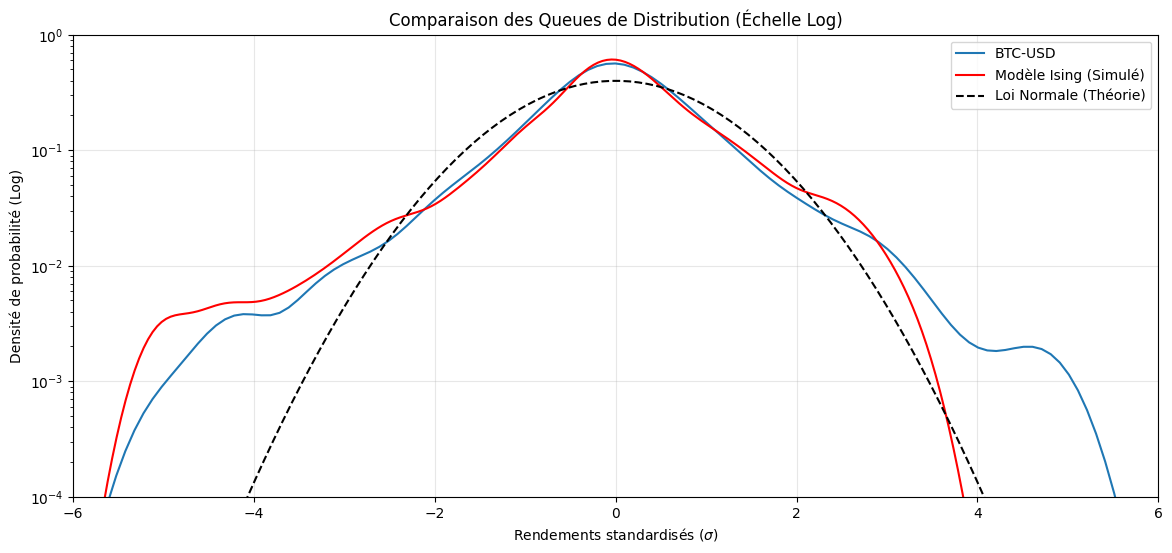

--- Résultats de l'Analyse ---
Volatilité (Ecart-type) : 0.02021738682113086
Asymétrie (Skewness) : -0.5623979062944213
Excès de Kurtosis : 3.316000200845155
Jarque-Bera p-value : 0.0
Est une Loi Normale ? : False
Susceptibility : 150.43946053009665


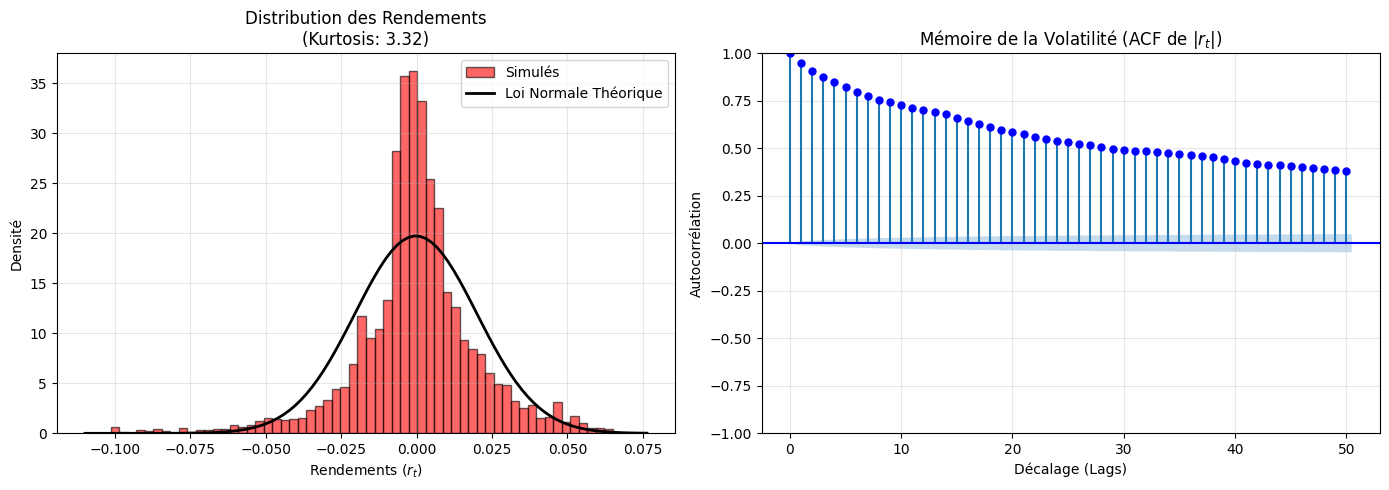

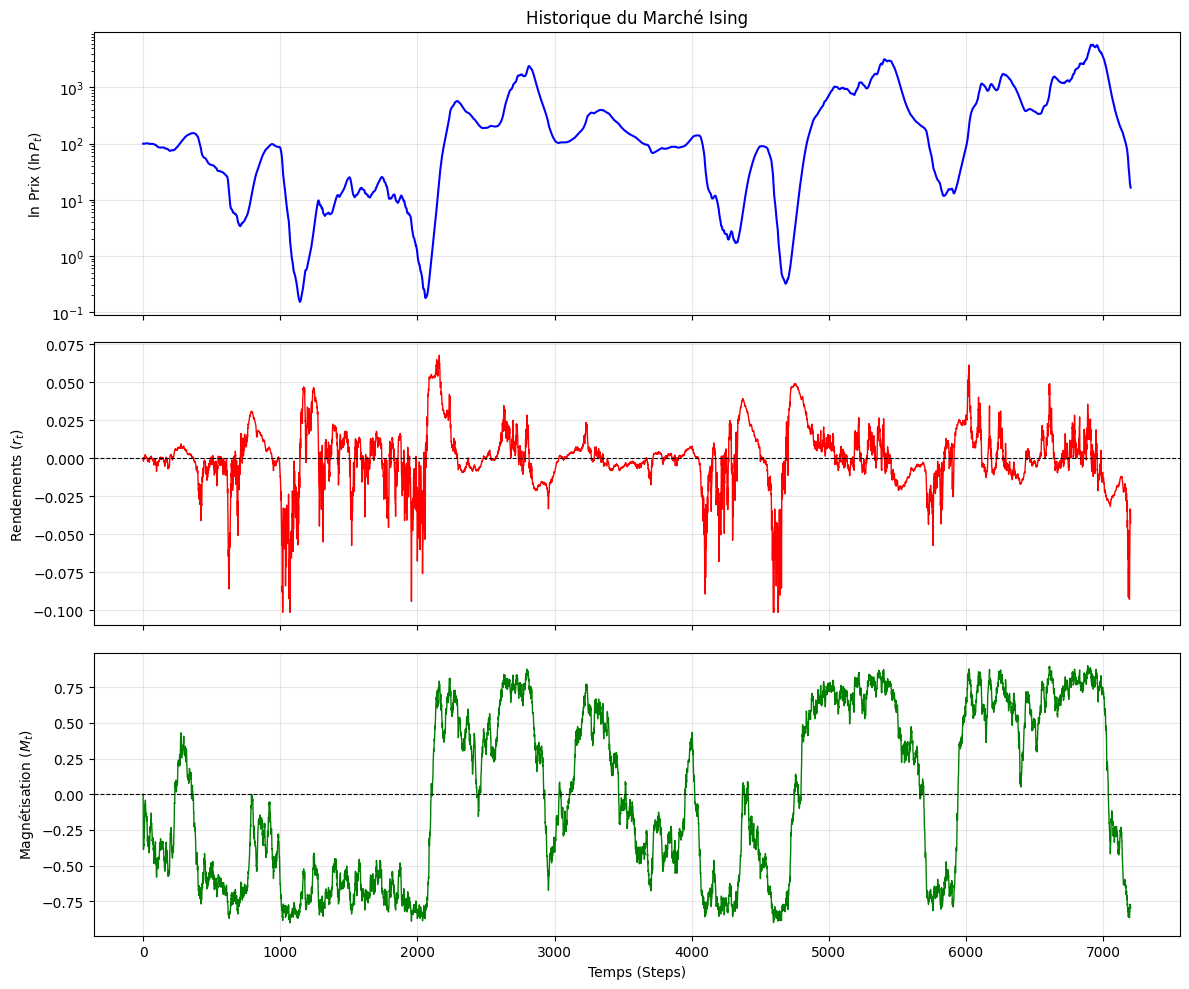

In [7]:
analyzer = MarketMetrics(df_results.loc[0,'file'])

compare_to_reality(analyzer.df['r_history'], real_returns) # Remplace chi_vals par tes r_t simulés

financial_stats = analyzer.analyze_returns()

print("--- Résultats de l'Analyse ---")
for metric, valeur in financial_stats.items():
    print(f"{metric} : {valeur}")
    
susceptibility = analyzer.calculate_susceptibility(N_agents, T)
print(f"Susceptibility : {susceptibility}")

# 3. Afficher les graphiques de validation (Histogramme + ACF)
analyzer.plot_stylized_facts()

curves(analyzer.df)